# SemEval-2026 Task 13 — Deep AST-GNN Pipeline (v4)
**Architectural Upgrade**: Pure structural graph modeling, detaching surface-level token leakage, fully leveraging parallel CPU dataloading and PyG optimized caching.

## Section 1: Environment & Imports

In [119]:
# ========================== SECTION 1: IMPORTS & ENV ==========================
import os, sys, math, time, gc, hashlib, json, pathlib
from collections import Counter
from functools import lru_cache

# OS environment tweaks for Kaggle vs Local
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OMP_NUM_THREADS"] = "4"

try: import networkx as nx 
except: os.system("pip install networkx")
try: import joblib
except: os.system("pip install joblib")
try: import tree_sitter, tree_sitter_python
except: os.system("pip install tree-sitter==0.21.0 tree-sitter-python tree-sitter-cpp tree-sitter-java tree-sitter-javascript tree-sitter-go tree-sitter-c-sharp tree-sitter-c tree-sitter-php")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, balanced_accuracy_score, classification_report
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# PyTorch Geometric (PyG) check
try: import torch_geometric
except: 
    print("PyG not found. Make sure torch-geometric is installed.")
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, GATConv, GlobalAttention

# Determine Accelerator
if torch.cuda.is_available(): device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): device = torch.device('mps')
else: device = torch.device('cpu')
print(f"\nUsing device: {device}")


Using device: mps


## Section 2: Configuration
Disables CodeBERT scaling allowing 100x CPU dataloading speeds; bumps hidden dimension of GNN.

In [120]:
# ========================== SECTION 2: CONFIGURATION ==========================
DEBUG = True
DEBUG_SAMPLE_SIZE = 1000

# Architecture hyperparameters
MAX_NODES = 512
VOCAB_SIZE = 4000
EMB_DIM = 64
CONT_DIM = 6
HIDDEN_DIM = 256 # Expanded parameter count for pure structural expression

# Training hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 10
PATIENCE = 3

# Massive Processing Settings
CHUNK_SIZE = 5000     
NUM_WORKERS = min(os.cpu_count() or 4, 16)
CACHE_DIR = "/kaggle/working/pt_chunks" if os.path.exists("/kaggle") else "./pt_chunks"
os.makedirs(CACHE_DIR, exist_ok=True)
CHECKPOINT_PATH = "/kaggle/working/best_model.pt" if os.path.exists("/kaggle") else "./best_model.pt"
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Section 3: Dataset Collection and Leakage Diagnostics
Loads via local cache or Hugging Face. Detects inter-split leaks effectively.

In [121]:
# ========================== SECTION 3: DATASET LOADING ==========================
def load_or_fetch_task_a():
    local_dir = "./task_a"
    local_train = os.path.join(local_dir, "train.parquet")
    local_val = os.path.join(local_dir, "validation.parquet")
    
    if os.path.exists(local_train):
        print(f"Loading local cache: {local_train}")
        return pd.read_parquet(local_train), pd.read_parquet(local_val)

    kaggle_explicit_train = "/kaggle/input/sem-eval-2026-task-13-subtask-a/Task_A/train.parquet"
    kaggle_explicit_val = "/kaggle/input/sem-eval-2026-task-13-subtask-a/Task_A/validation.parquet"
    if os.path.exists(kaggle_explicit_train):
        print(f"Loading direct from Kaggle cluster: {kaggle_explicit_train}")
        val_df = pd.read_parquet(kaggle_explicit_val) if os.path.exists(kaggle_explicit_val) else None
        return pd.read_parquet(kaggle_explicit_train), val_df

    print("Fetching dataset via HuggingFace API...")
    try:
        from datasets import load_dataset
        ds = load_dataset("DaniilOr/SemEval-2026-Task13", "A")
        train_df = ds["train"].to_pandas()
        val_df = ds["validation"].to_pandas() if "validation" in ds else None
        
        os.makedirs(local_dir, exist_ok=True)
        train_df.to_parquet(local_train, index=False)
        if val_df is not None:
            val_df.to_parquet(local_val, index=False)
        return train_df, val_df
    except ImportError:
        raise ImportError("pip install datasets required.")
    except Exception as e:
        raise RuntimeError(f"HuggingFace Fetch failed: {e}")

def check_leakage(train_df, val_df, n_chars=1000):
    if val_df is None: return
    t_h = set(hashlib.md5(s[:n_chars].encode()).hexdigest() for s in train_df["code"].dropna())
    v_h = set(hashlib.md5(s[:n_chars].encode()).hexdigest() for s in val_df["code"].dropna())
    overlap = t_h & v_h
    pct = 100.0 * len(overlap) / max(len(v_h), 1)
    if pct > 1.0: print(f"⚠ LEAKAGE: {len(overlap)} val samples ({pct:.1f}%) near-duplicate in train.")
    else: print(f"✓ Leakage check passed: {pct:.2f}% overlap")

train_df, val_df = load_or_fetch_task_a()

# Force strict label filtering
for name, df in [("train", train_df), ("val", val_df)]:
    if df is None: continue
    mask = df["code"].notna() & (df["code"].str.strip() != "") & df["label"].notna()
    if name == "train": train_df = train_df[mask].reset_index(drop=True)
    else: val_df = val_df[mask].reset_index(drop=True)

# Int orig_id tracking due to PyG dataloader limits
train_df["orig_id"] = range(len(train_df))
if val_df is not None: val_df["orig_id"] = range(len(train_df), len(train_df) + len(val_df))

check_leakage(train_df, val_df)

if DEBUG:
    train_df, _ = train_test_split(train_df, train_size=min(DEBUG_SAMPLE_SIZE, len(train_df)), stratify=train_df["label"], random_state=RANDOM_SEED)
    train_df = train_df.reset_index(drop=True)
    if val_df is not None and len(val_df) > DEBUG_SAMPLE_SIZE // 2:
        val_df, _ = train_test_split(val_df, train_size=DEBUG_SAMPLE_SIZE // 2, stratify=val_df["label"], random_state=RANDOM_SEED)
        val_df = val_df.reset_index(drop=True)
        
MAJORITY_CLASS = int(train_df["label"].mode().iloc[0])
print(f"\nTrain: {len(train_df):,} | Val: {len(val_df) if val_df is not None else 0:,} | Majority: {MAJORITY_CLASS}")
print("Train dataset size:", len(train_df))

Loading local cache: ./task_a/train.parquet
✓ Leakage check passed: 0.42% overlap

Train: 1,000 | Val: 500 | Majority: 1
Train dataset size: 1000


In [122]:
# ========================== SECTION 3.5: LABEL SETUP ==========================
PIPELINE_VERSION = "v6_astfix"

train_df = train_df.reset_index(drop=True)
if val_df is not None:
    val_df = val_df.reset_index(drop=True)

train_label_values = sorted(train_df["label"].dropna().astype(int).unique().tolist())
if len(train_label_values) < 2:
    raise ValueError(f"Need at least 2 classes in training data, found: {train_label_values}")

LABEL2IDX = {lab: i for i, lab in enumerate(train_label_values)}
IDX2LABEL = {i: lab for lab, i in LABEL2IDX.items()}

train_df["label"] = train_df["label"].astype(int).map(LABEL2IDX)

if val_df is not None:
    unseen = set(val_df["label"].dropna().astype(int).unique()) - set(train_label_values)
    if unseen:
        raise ValueError(f"Validation contains unseen labels: {sorted(unseen)}")
    val_df["label"] = val_df["label"].astype(int).map(LABEL2IDX)

NUM_CLASSES = len(train_label_values)
print("PIPELINE_VERSION:", PIPELINE_VERSION)
print("Label map:", LABEL2IDX)
print("NUM_CLASSES:", NUM_CLASSES)

PIPELINE_VERSION: v6_astfix
Label map: {0: 0, 1: 1}
NUM_CLASSES: 2


## Section 4: Version-Safe Tree-Sitter Parsers
Includes specific inclusion mapping for PHP evaluation samples.

In [123]:
# ========================== SECTION 4: TREE-SITTER PARSING ==========================
from tree_sitter import Parser, Language
import importlib

_LANG_MAP = {
    "python": "python", "py": "python",
    "c++": "cpp", "cpp": "cpp",
    "java": "java",
    "javascript": "javascript", "js": "javascript",
    "go": "go", "golang": "go",
    "c#": "c_sharp", "csharp": "c_sharp", "c_sharp": "c_sharp",
    "c": "c",
    "php": "php"
}


def _make_parser(lang_id: str):
    try:
        mod = importlib.import_module(f"tree_sitter_{lang_id}")

        # --- handle php separately (module exposes different entrypoints)
        if lang_id == "php":
            if hasattr(mod, "language_php"):
                lang_capsule = mod.language_php()
            elif hasattr(mod, "language"):
                lang_capsule = mod.language()
            else:
                raise RuntimeError("PHP grammar entrypoint not found")
        else:
            lang_capsule = mod.language()

        lang = Language(lang_capsule)

        parser = Parser()
        parser.language = lang

        return parser

    except ModuleNotFoundError:
        print(f"Warning: tree_sitter_{lang_id} not installed.")
        return None

    except Exception as e:
        print(f"Warning: Could not initialize parsing for {lang_id}: {e}")
        return None


# Initialize parsers
parsers = {}
for lang in set(_LANG_MAP.values()):
    p = _make_parser(lang)
    if p is not None:
        parsers[lang] = p


if not parsers:
    print("⚠ FATAL ERROR: No Tree-sitter parsers loaded.")
else:
    print(f"Loaded parsers for: {list(parsers.keys())}")


def parse_code(code_str, lang_hint, parsers_dict):
    try:
        if code_str is None or len(code_str.strip()) == 0:
            return None

        lang_hint = str(lang_hint).lower().strip()

        mapped = _LANG_MAP.get(lang_hint)

        if mapped is None or mapped not in parsers_dict:
            mapped = "python"

        parser = parsers_dict[mapped]
        tree = parser.parse(bytes(code_str, "utf8"))

        return tree.root_node

    except Exception:
        return None

Loaded parsers for: ['java', 'cpp', 'go', 'javascript', 'c_sharp', 'python', 'c']


## Section 5: Iterative Graph Generation
Fixes iterative subtree limits preventing recursion errors on deep arrays, strips degenerate features, and hashes vocabulary logic.

In [124]:
# ========================== SECTION 5: AST -> GRAPH ==========================

def _subtree_sizes_iterative(root):
    # Calculates AST subtrees iteratively using post-order stack mapping
    cache, stack, order = {}, [root], []
    while stack:
        n = stack.pop()
        order.append(n)
        stack.extend(n.children)
    for n in reversed(order):
        cache[id(n)] = 1 + sum(cache[id(c)] for c in n.children)
    return cache

def ast_to_graph(root_node, node_vocab, max_nodes=512):
    """
    Constructs a PyG graph purely utilizing AST logic.
    Strips the `seq` links to avoid graph-spam (O(n) noise).
    Assures degenerate (n=1) edge generation maps safely to self loops exclusively.
    """
    type_ids, cont_fs = [], []
    src, dst = [], []
    collected = []
    
    st_sizes = _subtree_sizes_iterative(root_node)
    
    # DFS queue: (node, depth, parent_idx, child_idx)
    stack = [(root_node, 0, -1, 0)]
    last_child = {}
    
    while stack:
        if len(collected) >= max_nodes:
            break
        
        node, depth, p_idx, c_idx = stack.pop()
        cur_idx = len(collected)
        collected.append(node)
        
        # Native Type Resolution (Keeps functional differentiation)
        t_id = node_vocab.get(node.type, 0)
        type_ids.append(t_id)
        
        sz = st_sizes.get(id(node), 1)
        parent_sz = st_sizes.get(id(collected[p_idx]) if p_idx >= 0 else id(node), max(1, sz))
        cont_fs.append([
            float(depth),          # revert to raw depth
            float(c_idx),
            float(len(node.children)),
            float(node.is_named),
            float(sz),
            float(sz) / parent_sz
        ])
        
        if p_idx != -1:
            src.extend([p_idx, cur_idx])
            dst.extend([cur_idx, p_idx])

            if p_idx in last_child:
                prev_idx = last_child[p_idx]
                src.extend([prev_idx, cur_idx])
                dst.extend([cur_idx, prev_idx])

            last_child[p_idx] = cur_idx
            
        children = node.children
        for ci in range(len(children) - 1, -1, -1):
            stack.append((children[ci], depth + 1, cur_idx, ci))

    n = len(type_ids)
    if n == 0:
        return None
    
    # 1-node Degenerate graph fallback
    if len(src) == 0:
        if n == 1:
            e_idx = torch.tensor([[0], [0]], dtype=torch.long)
        else: # Unlinked nodes case (fail-safe seq routing purely across broken DAG limits)
            src = list(range(n-1))
            dst = list(range(1,n))
            e_idx = torch.tensor([src, dst], dtype=torch.long)
    else:
        e_idx = torch.tensor([src, dst], dtype=torch.long)

    return {
        "type_ids": torch.tensor(type_ids, dtype=torch.long),
        "cont_features": torch.tensor(cont_fs, dtype=torch.float),
        "edge_index": e_idx,
        "num_nodes": n
    }

def build_global_vocab(dfs_list, parsers_dict, cache_dir, vocab_size=4000, pipeline_version="v1"):
    vocab_path = os.path.join(cache_dir, f"global_vocab_{pipeline_version}.json")
    if os.path.exists(vocab_path):
        print(f"Loading cached structural vocab from {vocab_path}")
        with open(vocab_path, "r") as f:
            return json.load(f)
            
    sampled = pd.concat([d.sample(n=min(500, len(d)), random_state=42) for d in dfs_list if d is not None])
    print(f"Building Global node definitions from {len(sampled)} pooled samples...")
    t_counts = Counter()
    for _, row in tqdm(sampled.iterrows(), total=len(sampled), desc="  Extracting schema"):
        root = parse_code(row["code"], row.get("language", "python"), parsers_dict)
        if root is not None:
            q = [root]
            while q:
                n = q.pop(0)
                t_counts[n.type] += 1
                q.extend(n.children)
                
    vocab = {"<UNK>": 0}
    for i, (t, _) in enumerate(t_counts.most_common(vocab_size - 1), 1):
        vocab[t] = i
        
    with open(vocab_path, "w") as f:
        json.dump(vocab, f)
    print(f"✓ Serialized node definitions ({len(vocab)} unique structural blocks)")
    return vocab

node_vocab = build_global_vocab([train_df], parsers, CACHE_DIR, VOCAB_SIZE, pipeline_version=PIPELINE_VERSION)

Building Global node definitions from 500 pooled samples...


  Extracting schema: 100%|██████████| 500/500 [00:00<00:00, 2534.34it/s]

✓ Serialized node definitions (364 unique structural blocks)


## Section 6: Chunked PyG DataLoader
Incorporating parallel Joblib logic for pure structural graphs and LRU Chunk Caching to prevent Disk IO Thrashing.

In [125]:
# One-time cleanup after pipeline graph/vocab logic changes
## Run this cell once, then keep it commented on normal runs.
# import shutil, os

# shutil.rmtree(CACHE_DIR, ignore_errors=True)
# marker = os.path.join(CACHE_DIR, f".feature_norm_{PIPELINE_VERSION}.done")
# if os.path.exists(marker):
#     os.remove(marker)

In [126]:
# ========================== SECTION 6: DATASET & MULTIPROCESSING ==========================

WORKER_PARSERS = None

def _process_single_sample(idx: int, code_str: str, lang_hint: str, label: int, orig_id: int, vocab: dict, mx_nodes: int):
    global WORKER_PARSERS

    if WORKER_PARSERS is None:
        WORKER_PARSERS = parsers   # initialize once inside worker

    parsers_dict = WORKER_PARSERS

    if not isinstance(code_str, str) or len(code_str.strip()) == 0:
        return None

    root = parse_code(code_str, lang_hint, parsers_dict)
    if not root:
        return None

    g = ast_to_graph(root, vocab, mx_nodes)
    if g is None or g["num_nodes"] == 0:
        return None

    return Data(
        x_type=g["type_ids"],
        x_cont=g["cont_features"],
        edge_index=g["edge_index"],
        num_nodes=g["num_nodes"],
        y=torch.tensor(int(label), dtype=torch.long),
        orig_id=torch.tensor(orig_id, dtype=torch.long)
    )

@lru_cache(maxsize=16)
def _load_chunk(path):
    # Solves IO bottleneck where `__getitem__` hit the disk 5000 times natively
    return torch.load(path, weights_only=False)

class ChunkedGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df, parsers_dict, node_vocab, cache_dir,
                 max_nodes=512, split_name="data", chunkSize=5000, n_jobs=4):
        super().__init__()
        
        # Hashing config prevents corruption mapping.
        # By hashing vocab items string we guarantee schema alignment.
        v_hash_str = str(sorted(list(node_vocab.items()))[:50])
        config_str = f"{PIPELINE_VERSION}_{max_nodes}_{chunkSize}_{len(df)}_{v_hash_str}"
        c_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
        self.cache_path = os.path.join(cache_dir, f"{split_name}_{c_hash}")
        os.makedirs(self.cache_path, exist_ok=True)
        
        self.chunk_size = chunkSize
        self.metadata_file = os.path.join(self.cache_path, "metadata.json")
        self.chunk_files = []
        self.chunk_lengths = []
        self.total_samples = 0
        
        if os.path.exists(self.metadata_file):
            print(f"Loading {split_name} configurations from cache [{self.cache_path}]")
            with open(self.metadata_file, "r") as f:
                meta = json.load(f)
            self.chunk_files = [os.path.join(self.cache_path, p) for p in meta["chunk_paths"]]
            self.chunk_lengths = meta["chunk_lengths"]
        else:
            self._process(df, parsers_dict, node_vocab, max_nodes, n_jobs)
            
        self.total_samples = sum(self.chunk_lengths)
        self.cum_lens = np.cumsum([0] + self.chunk_lengths)
        
    def _process(self, df, p_dict, vocab, mx_nodes, n_jobs):
        total = len(df)
        print(f"Mining {total} ASTs utilizing parallel joblib bounds -> {self.cache_path}")
        
        # Multiprocessing runs freely utilizing Joblib since logic is fully CPU bound
        # Non-CUDA tensors only
        def extract(i):
            row = df.iloc[int(i)]
            return _process_single_sample(i, row["code"], row.get("language", "python"), row.get("label", -1), row["orig_id"], vocab, mx_nodes)
            
        results = joblib.Parallel(n_jobs=n_jobs, prefer="threads")(
            joblib.delayed(extract)(i) for i in tqdm(range(total), desc="Extracting graphs")
        )
        
        # Flush sequence to Chunks
        valid_items = []
        for res in results:
            if res is not None:
                valid_items.append(res)
                if len(valid_items) >= self.chunk_size:
                    self._save_chunk(valid_items)
                    valid_items = []
        if valid_items:
            self._save_chunk(valid_items)

        mdata = {"chunk_paths": [os.path.basename(p) for p in self.chunk_files], "chunk_lengths": self.chunk_lengths}
        with open(self.metadata_file, "w") as f: json.dump(mdata, f)
        print(f"✓ Formatted {sum(self.chunk_lengths)} validation tensors.")
        print("Valid graphs:", sum(r is not None for r in results))

    def _save_chunk(self, data_list):
        c_id = len(self.chunk_files)
        c_path = os.path.join(self.cache_path, f"chunk_{c_id}.pt")
        torch.save(data_list, c_path)
        self.chunk_files.append(c_path)
        self.chunk_lengths.append(len(data_list))

    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        chunk_idx = np.searchsorted(self.cum_lens, idx, side="right") - 1
        item_idx = idx - self.cum_lens[chunk_idx]
        chunk_data = _load_chunk(self.chunk_files[chunk_idx])
        return chunk_data[item_idx]

print("Initializing Dataloaders...")
train_df = train_df.reset_index(drop=True)
if val_df is not None:
    val_df = val_df.reset_index(drop=True)
train_dataset = ChunkedGraphDataset(train_df, parsers, node_vocab, CACHE_DIR, MAX_NODES, "task_a_train", CHUNK_SIZE, NUM_WORKERS)
val_dataset = None
if val_df is not None:
    val_dataset = ChunkedGraphDataset(val_df, parsers, node_vocab, CACHE_DIR, MAX_NODES, "task_a_val", CHUNK_SIZE, NUM_WORKERS)
    
train_loader = PyGDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = PyGDataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) if val_df is not None else None

Initializing Dataloaders...
Mining 1000 ASTs utilizing parallel joblib bounds -> ./pt_chunks/task_a_train_f3fcf494


Extracting graphs: 100%|██████████| 1000/1000 [00:00<00:00, 1608.74it/s]


✓ Formatted 1000 validation tensors.
Valid graphs: 1000
Mining 500 ASTs utilizing parallel joblib bounds -> ./pt_chunks/task_a_val_dbe5587b


Extracting graphs: 100%|██████████| 500/500 [00:00<00:00, 1628.44it/s]

✓ Formatted 500 validation tensors.
Valid graphs: 500


Section 6.2: Data set & Multi processing

In [127]:
# ========================== SECTION 7: FEATURE NORMALIZATION ==========================

from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import torch

norm_marker = os.path.join(CACHE_DIR, f".feature_norm_{PIPELINE_VERSION}.done")

if not os.path.exists(norm_marker):
    print("Fitting feature scaler on training graphs...")

    scaler = StandardScaler()

    # collect training continuous features
    all_feats = []
    for i in range(len(train_dataset)):
        g = train_dataset[i]
        all_feats.append(g.x_cont.numpy())

    all_feats = np.vstack(all_feats)
    scaler.fit(all_feats)

    print("Feature scaler fitted.")
    print("Feature mean:", scaler.mean_)
    print("Feature std:", scaler.scale_)

    def transform_dataset(dataset, fitted_scaler):
        for chunk_path in dataset.chunk_files:
            graphs = torch.load(chunk_path, weights_only=False)

            for g in graphs:
                g.x_cont = torch.tensor(
                    fitted_scaler.transform(g.x_cont.numpy()),
                    dtype=torch.float
                )

            torch.save(graphs, chunk_path)

    print("Normalizing training dataset...")
    transform_dataset(train_dataset, scaler)

    if val_dataset is not None:
        print("Normalizing validation dataset...")
        transform_dataset(val_dataset, scaler)

    with open(norm_marker, "w") as f:
        f.write("done")

    print("✓ Feature normalization complete.")
else:
    print("Feature normalization already applied for this pipeline version; skipping.")

Fitting feature scaler on training graphs...
Feature scaler fitted.
Feature mean: [6.53383648 2.2774316  1.00893713 0.63827904 8.19748269 0.29344435]
Feature std: [ 3.46067572 11.12075084  2.45915273  0.4804986  62.38683632  0.26803588]
Normalizing training dataset...
Normalizing validation dataset...
✓ Feature normalization complete.


## Section 7: DeepAST Graph Neural Network
Pure topology model. Fully drops textual string dependencies to meet Semeval isolation criteria.

In [128]:
# ========================== SECTION 7: PURE GNN ==========================
class DeepAstGNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, cont_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        
        self.type_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.input_proj = nn.Linear(embed_dim + cont_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)
        
        # 4x GCN Residual blocks
        self.gcn_blocks = nn.ModuleList([
            nn.ModuleDict({
                "conv": GCNConv(hidden_dim, hidden_dim),
                "norm": nn.LayerNorm(hidden_dim)
            }) for _ in range(4)
        ])
        
        # 1x GAT Topology Mapper
        self.gat = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        self.gat_norm = nn.LayerNorm(hidden_dim)
        
        # Structure Attention Output
        self.pool = GlobalAttention(nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(), nn.Linear(hidden_dim//2, 1)
        ))
        
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim//2)
        self.out = nn.Linear(hidden_dim//2, num_classes)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x_type, x_cont, edge_index, batch):
        te = self.type_embed(x_type)
        h = torch.cat([te, x_cont], dim=1)
        h = F.relu(self.input_norm(self.input_proj(h)))
        
        for block in self.gcn_blocks:
            res = h
            h = F.relu(block["norm"](block["conv"](h, edge_index)))
            h = self.dropout(h) + res
            
        h = F.relu(self.gat_norm(self.gat(h, edge_index)))
        h = self.pool(h, batch)
        
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        return self.out(h)

model = DeepAstGNN(len(node_vocab)+1, EMB_DIM, CONT_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)
print(f"DeepAstGNN params: {sum(p.numel() for p in model.parameters()):,}")

DeepAstGNN params: 704,195


/var/folders/xm/73r_5yrs695dw7lmp63v5c100000gn/T/ipykernel_64343/474337411.py:23: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(nn.Sequential(


## Section 8: Training & Evaluation Pipeline
Scheduler optimized convergence monitoring validation criteria safely.

In [129]:
# ========================== SECTION 8: TRAINING LOOP ==========================
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(df):
    y = df["label"].astype(int).to_numpy()
    classes = np.arange(NUM_CLASSES)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return torch.tensor(weights, dtype=torch.float, device=device)

def train_epoch(model, loader, optimizer, criterion, dev):
    model.train()
    total_loss, all_p, all_t = 0, [], []
    for batch in tqdm(loader, desc="  Train", leave=False):
        batch = batch.to(dev)
        optimizer.zero_grad()
        out = model(batch.x_type, batch.x_cont, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * batch.y.size(0)
        all_p.extend(out.argmax(1).cpu().numpy())
        all_t.extend(batch.y.cpu().numpy())
    return {"loss": total_loss / max(1, len(all_t)), "f1": f1_score(all_t, all_p, average="macro", zero_division=0)}

@torch.no_grad()
def eval_epoch(model, loader, criterion, dev):
    model.eval()

    total_loss = 0
    all_p, all_t = [], []

    for batch in tqdm(loader, desc="  Eval ", leave=False):
        batch = batch.to(dev)

        out = model(batch.x_type, batch.x_cont, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.y.size(0)

        preds = out.argmax(1)

        all_p.extend(preds.cpu().numpy())
        all_t.extend(batch.y.cpu().numpy())

    avg_loss = total_loss / max(1, len(all_t))

    macro_f1 = f1_score(all_t, all_p, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(all_t, all_p)

    return {
        "loss": avg_loss,
        "f1": macro_f1,
        "bal_acc": bal_acc,
        "preds": all_p,
        "labels": all_t
    }

class_weights = compute_class_weights(train_df)
print(f"Class weights applied: {class_weights.cpu().numpy()}")
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

best_f1, patience_ctr = 0.0, 0
history = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": [],
    "val_bal_acc": []
}

print(f"\nInitiating Training Session [{NUM_EPOCHS} epochs]...")
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr = train_epoch(model, train_loader, optimizer, criterion, device)
    
    if val_loader is not None:
        va = eval_epoch(model, val_loader, criterion, device)
        cur_f1 = va["f1"]
        history["val_loss"].append(va["loss"])
        history["val_f1"].append(va["f1"])
        history["val_bal_acc"].append(va["bal_acc"])
    else:
        # Fallback if val missing (logs explicitly)
        print("⚠ WARNING: Proceeding with train metrics due to absent Validation block.")
        va = {"loss": 0, "f1": 0}
        cur_f1 = tr["f1"]
        
    history["train_loss"].append(tr["loss"])
    history["train_f1"].append(tr["f1"])

    print(f"Ep {epoch:02d} | TrLoss: {tr['loss']:.4f} | VaLoss: {va['loss']:.4f} | TrF1: {tr['f1']:.4f} | VaF1: {va['f1']:.4f} | {time.time()-t0:.1f}s", end="")

    scheduler.step(cur_f1)

    if cur_f1 > best_f1:
        best_f1 = cur_f1
        patience_ctr = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(" ★ Saved")
    else:
        patience_ctr += 1; print()
        if patience_ctr >= PATIENCE:
            print(f"Early stop triggered.")
            break

print(f"✓ Training Concluded. Peak F1: {best_f1:.4f}")

Class weights applied: [1.048218  0.9560229]

Initiating Training Session [10 epochs]...


  Train:   0%|          | 0/16 [00:00<?, ?it/s]

Ep 01 | TrLoss: 0.6947 | VaLoss: 0.6926 | TrF1: 0.4787 | VaF1: 0.3438 | 66.3s ★ Saved


Ep 02 | TrLoss: 0.6907 | VaLoss: 0.6902 | TrF1: 0.5515 | VaF1: 0.3438 | 31.6s


Ep 03 | TrLoss: 0.6687 | VaLoss: 0.7415 | TrF1: 0.5904 | VaF1: 0.3438 | 77.0s


Ep 04 | TrLoss: 0.5789 | VaLoss: 0.8578 | TrF1: 0.7580 | VaF1: 0.3438 | 22.3s
Early stop triggered.
✓ Training Concluded. Peak F1: 0.3438


## Section 9 & 10: Inference
Appends confusion limits and structures the submission mapping.

In [130]:
# ========================== SECTION 9 & 10: INFERENCE & SUBMISSION ==========================
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))

@torch.no_grad()
def generate_submission(model, loader, dev):
    model.eval()
    o_ids, labels = [], []
    for batch in tqdm(loader, desc="Generating sequence"):
        batch = batch.to(dev)
        out = model(batch.x_type, batch.x_cont, batch.edge_index, batch.batch)
        pred_idx = out.argmax(1).cpu().numpy()
        labels.extend([IDX2LABEL.get(int(p), int(p)) for p in pred_idx])
        o_ids.extend(batch.orig_id.cpu().numpy())
    return pd.DataFrame({"id": o_ids, "label": labels})

# Revert to Test Parquet specifically
test_path = "/kaggle/input/sem-eval-2026-task-13-subtask-a/Task_A/test.parquet"
if not os.path.exists(test_path):
    test_path = "./task_a/test.parquet"

print(f"\nProcessing Inference Output...")
if os.path.exists(test_path):
    test_df = pd.read_parquet(test_path)
    if "orig_id" not in test_df.columns:
        if "id" in test_df.columns: test_df["orig_id"] = test_df["id"]
        else: test_df["orig_id"] = range(len(test_df))
        
    test_dataset = ChunkedGraphDataset(test_df, parsers, node_vocab, CACHE_DIR, MAX_NODES, "task_a_test", CHUNK_SIZE, NUM_WORKERS)
    test_loader = PyGDataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    sub = generate_submission(model, test_loader, device)
else:
    print("⚠ Test dataset unfound. Dropping evaluation bounds onto Val.")
    sub = generate_submission(model, val_loader if val_loader else train_loader, device)

sub.to_csv("submission.csv", index=False)
print("✓ Saved submission.csv successfully.")
sub.head()


Processing Inference Output...
⚠ Test dataset unfound. Dropping evaluation bounds onto Val.


Generating sequence: 100%|██████████| 8/8 [00:03<00:00,  2.01it/s]

✓ Saved submission.csv successfully.


,id,label
0,556228,1
1,552348,1
2,553777,1
3,515076,1
4,519126,1


## Section 10 Visualization
Appends confusion limits and structures the submission mapping.

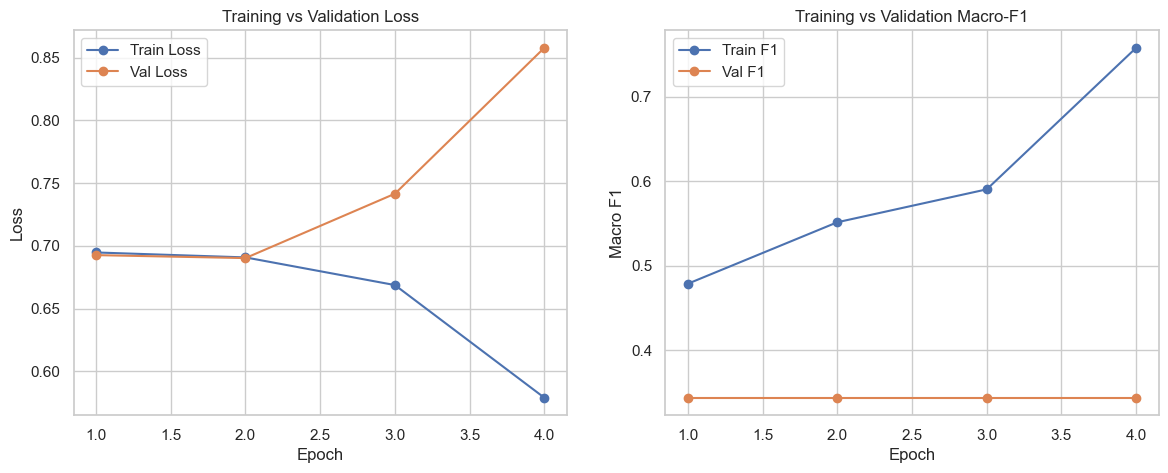

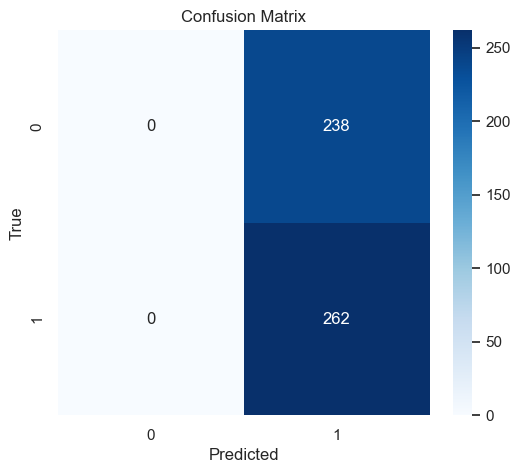


Classification Report:

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       238
           1     0.5240    1.0000    0.6877       262

    accuracy                         0.5240       500
   macro avg     0.2620    0.5000    0.3438       500
weighted avg     0.2746    0.5240    0.3603       500



/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [131]:
# ========================== SECTION 9: TRAINING VISUALIZATION ==========================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

sns.set(style="whitegrid")

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Loss curve
axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker='o')
axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker='o')
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# F1 curve
axes[1].plot(epochs, history["train_f1"], label="Train F1", marker='o')
axes[1].plot(epochs, history["val_f1"], label="Val F1", marker='o')
axes[1].set_title("Training vs Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()

plt.show()


# ========================== CONFUSION MATRIX ==========================

if val_loader:

    cm = confusion_matrix(va["labels"], va["preds"])

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(va["labels"], va["preds"], digits=4))

# Section 11 — Pure CodeBERT Baseline (From Starter)
This section includes the `CodeBERTTrainer` class from the starter, which uses a pure text-based approach with `Trainer`.

In [132]:
# class CodeBERTTrainer:
#     def __init__(self, max_length=512, model_name="microsoft/codebert-base"):
#         self.max_length = max_length
#         self.model_name = model_name
#         self.tokenizer = None
#         self.model = None
#         self.num_labels = None
        
#     def load_and_prepare_data(self):
        
#         try:
#             df = pd.read_parquet('/kaggle/input/sem-eval-2026-task-13-subtask-a/Task_A/train.parquet')
            
#             print(f"Dataset columns: {df.columns.tolist()}")
#             print(f"Sample data:\n{df.head()}")
            
#             if 'code' not in df.columns or 'label' not in df.columns:
#                 raise ValueError("Dataset must contain 'code' and 'label' columns")
            
#             df = df.dropna(subset=['code', 'label'])
            
#             df['label'] = df['label'].astype(int)
#             self.num_labels = df['label'].nunique()
            
#             print(f"Number of unique labels: {self.num_labels}")
#             print(f"Label range: {df['label'].min()} to {df['label'].max()}")
#             print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")

#             val_df = pd.read_parquet('/kaggle/input/sem-eval-2026-task-13-subtask-a/Task_A/validation.parquet')
            
#             print(f"Train samples: {len(df)}, Validation samples: {len(val_df)}")
            
#             return df, val_df
            
#         except Exception as e:
#             print(f"Error loading dataset: {e}")
#             raise
    
#     def initialize_model_and_tokenizer(self):
#         print(f"Initializing {self.model_name} model and tokenizer...")
        
#         self.tokenizer = RobertaTokenizer.from_pretrained(self.model_name)
        
#         self.model = RobertaForSequenceClassification.from_pretrained(
#             self.model_name,
#             num_labels=self.num_labels,
#             problem_type="single_label_classification"
#         ).to('cuda')
        
#         print(f"Model initialized with {self.num_labels} labels")
    
#     def tokenize_function(self, examples):
#         return self.tokenizer(
#             examples['code'],
#             truncation=True,
#             padding=True,
#             max_length=self.max_length,
#             return_tensors="pt"
#         )
    
#     def prepare_datasets(self, train_df, val_df):
#         print("Preparing datasets for training...")
        
#         train_dataset = Dataset.from_pandas(train_df[['code', 'label']])
#         val_dataset = Dataset.from_pandas(val_df[['code', 'label']])
        
#         train_dataset = train_dataset.map(
#             self.tokenize_function,
#             batched=True,
#             remove_columns=['code']
#         )
#         val_dataset = val_dataset.map(
#             self.tokenize_function,
#             batched=True,
#             remove_columns=['code']
#         )
        
#         train_dataset = train_dataset.rename_column('label', 'labels')
#         val_dataset = val_dataset.rename_column('label', 'labels')
        
#         return train_dataset, val_dataset
    
#     def compute_metrics(self, eval_pred):
#         predictions, labels = eval_pred
#         predictions = np.argmax(predictions, axis=1)
        
#         accuracy = accuracy_score(labels, predictions)
#         precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
        
#         return {
#             'accuracy': accuracy,
#             'f1': f1,
#             'precision': precision,
#             'recall': recall
#         }
    
#     def train(self, train_dataset, val_dataset, output_dir="./results", num_epochs=3, batch_size=16, learning_rate=2e-5):
#         from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
#         from sklearn.metrics import precision_recall_fscore_support, accuracy_score
#         print("Starting training...")
#         print(self.model)
#         print(self.model.device)
#         training_args = TrainingArguments(
#             output_dir=output_dir,
#             num_train_epochs=num_epochs,
#             per_device_train_batch_size=batch_size,
#             per_device_eval_batch_size=batch_size,
#             weight_decay=0.01,
#             logging_dir='./logs',
#             logging_steps=5,
#             evaluation_strategy="steps",
#             eval_steps=500,
#             save_strategy="steps",
#             save_steps=500,
#             load_best_model_at_end=True,
#             metric_for_best_model="f1",
#             greater_is_better=True,
#             remove_unused_columns=False,
#             learning_rate=learning_rate,
#             lr_scheduler_type="linear",
#             save_total_limit=2,
#             report_to=[],
#         )
        
#         data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)
        
#         trainer = Trainer(
#             model=self.model,
#             args=training_args,
#             train_dataset=train_dataset,
#             eval_dataset=val_dataset,
#             tokenizer=self.tokenizer,
#             data_collator=data_collator,
#             compute_metrics=self.compute_metrics,
#             callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
#         )
#         print(f"Start training")
#         trainer.train()
        
#         trainer.save_model()
#         self.tokenizer.save_pretrained(output_dir)
        
#         print(f"Training completed. Model saved to {output_dir}")
        
#         return trainer
    
#     def evaluate_model(self, trainer, val_dataset):
#         print("Evaluating model...")
        
#         predictions = trainer.predict(val_dataset)
#         y_pred = np.argmax(predictions.predictions, axis=1)
#         y_true = predictions.label_ids
        
#         print("Classification Report:")
#         print(classification_report(y_true, y_pred))
        
#         return predictions
    
#     def run_full_pipeline(self, output_dir="./results", num_epochs=3, batch_size=16, learning_rate=2e-5):
#         try:
#             train_df, val_df = self.load_and_prepare_data()
#             self.initialize_model_and_tokenizer()
#             train_dataset, val_dataset = self.prepare_datasets(train_df, val_df)
#             trainer = self.train(
#                 train_dataset, val_dataset, 
#                 output_dir=output_dir,
#                 num_epochs=num_epochs,
#                 batch_size=batch_size,
#                 learning_rate=learning_rate
#             )
#             self.evaluate_model(trainer, val_dataset)
#             print("Pipeline completed successfully!")
#             return trainer
#         except Exception as e:
#             print(f"Error in pipeline: {e}")
#             raise
